# Read the AMP training data

In [1]:
import pandas as pd

timesteps = {
    1.0: pd.read_csv(f'data/AMP/timestep-style-1.csv'),
    0.8: pd.read_csv(f'data/AMP/timestep-style-08.csv'),
    0.5: pd.read_csv(f'data/AMP/timestep-style-05.csv'),
    0.2: pd.read_csv(f'data/AMP/timestep-style-02.csv'),
}
discriminator = {
    1.0: pd.read_csv(f'data/AMP/discriminator-style-1.csv'),
    0.8: pd.read_csv(f'data/AMP/discriminator-style-08.csv'),
    0.5: pd.read_csv(f'data/AMP/discriminator-style-05.csv'),
    0.2: pd.read_csv(f'data/AMP/discriminator-style-02.csv'),
}
reward = {
    1.0: pd.read_csv(f'data/AMP/reward-style-1.csv'),
    0.8: pd.read_csv(f'data/AMP/reward-style-08.csv'),
    0.5: pd.read_csv(f'data/AMP/reward-style-05.csv'),
    0.2: pd.read_csv(f'data/AMP/reward-style-02.csv'),
}
stats = {
    "Nagroda $r^G$": reward,
    "Czas Życia Agenta": timesteps,
    "Funkcja Straty Dyskryminatora": discriminator,
}

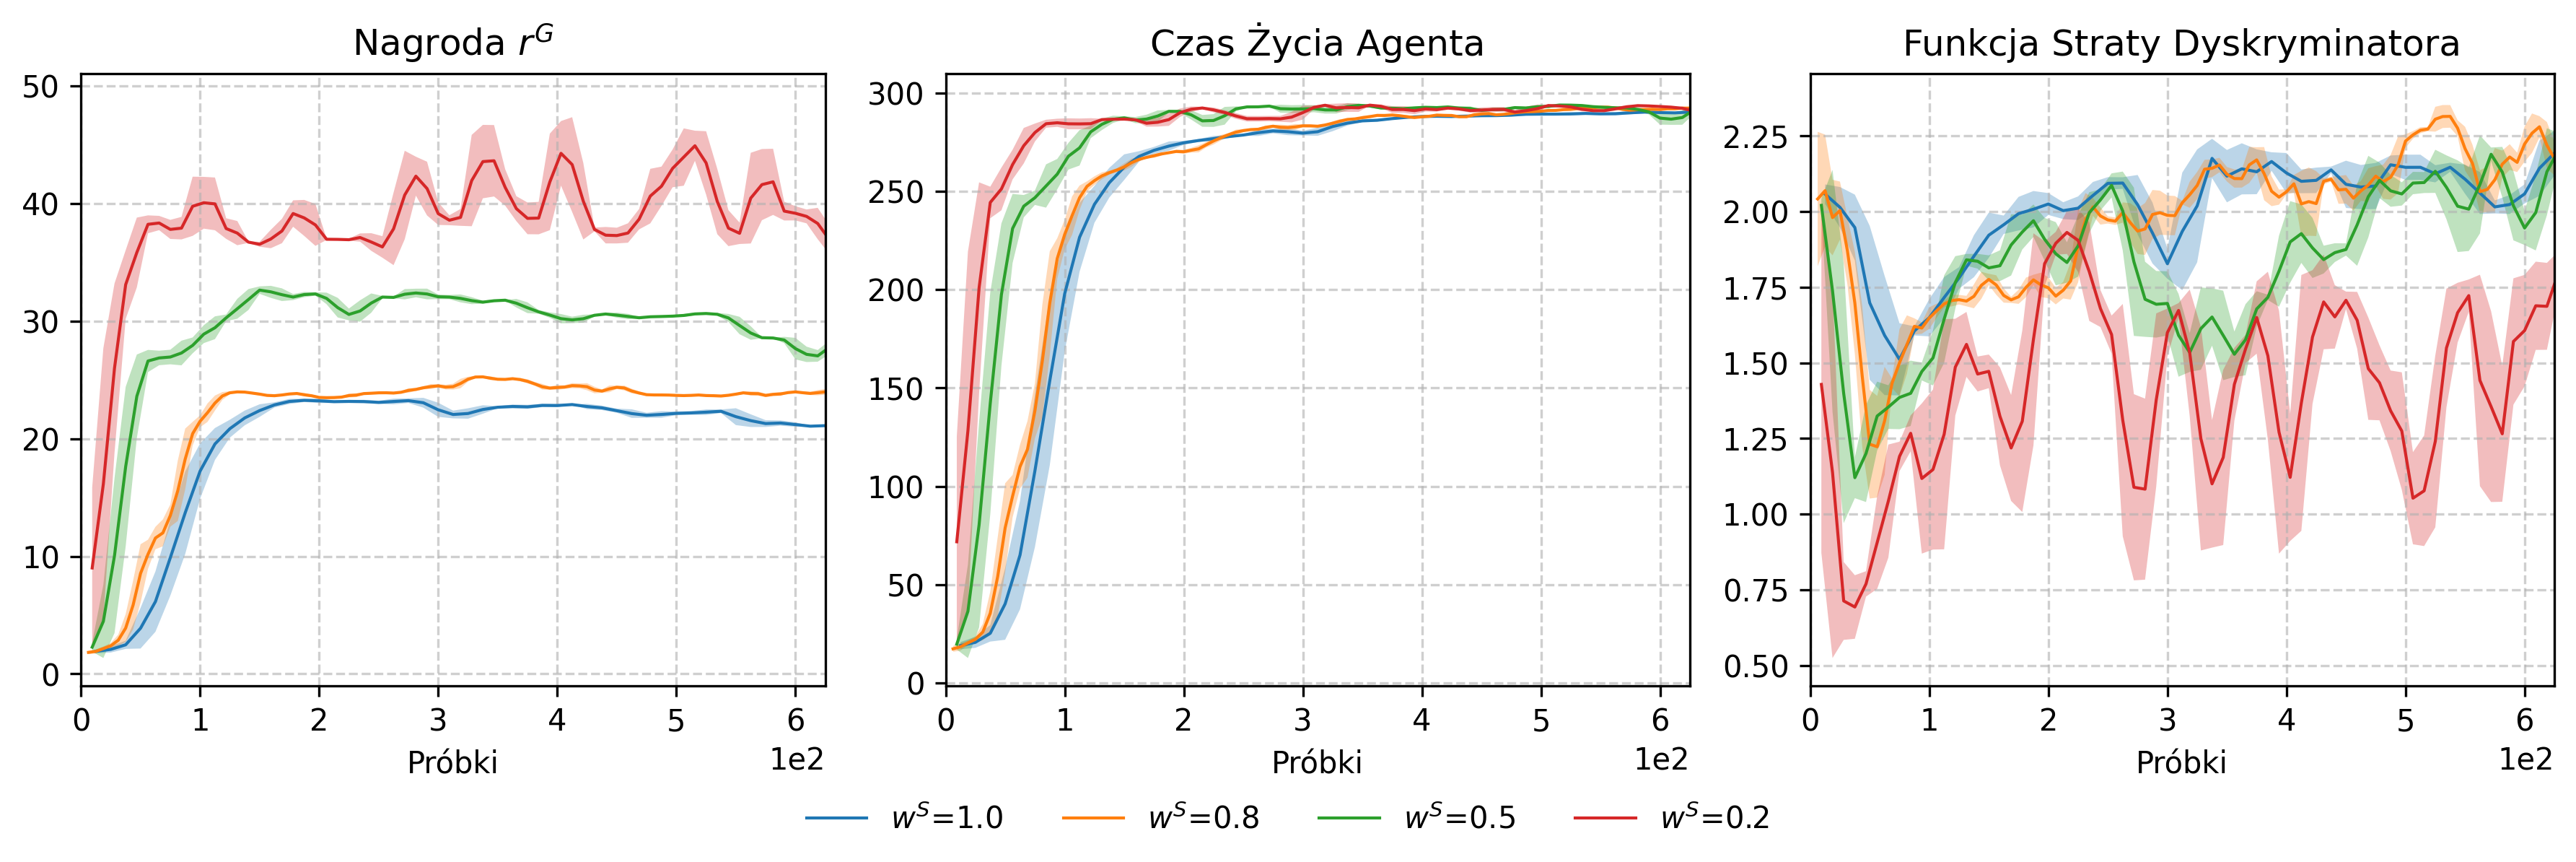

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def moving_stats(y, window=30):
    mean = np.array([
        y[max(0, i-window//2):min(len(y), i+window//2+1)].mean()
        for i in range(len(y))
    ])
    
    std = np.array([
        y[max(0, i-window//2):min(len(y), i+window//2+1)].std()
        for i in range(len(y))
    ])
    
    min_val = mean - std
    max_val = mean + std
    return mean, min_val, max_val

handles_all = []
labels_all = []


fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=300)
axes = axes.flatten()
for ax, (title, value) in zip(axes, stats.items()):
    for key, df in value.items():
        x = df['Step'].values / 64
        y = df['Value'].values

        mean, min_val, max_val = moving_stats(y, window=3)

        line, = ax.plot(x, mean, linewidth=1, label=f'$w^S$={key}')
        ax.fill_between(x, min_val, max_val, alpha=0.3)
        
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(0, 625)
    ax.set_xlabel('Próbki')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    handles, labels = ax.get_legend_handles_labels()
    for h, l in zip(handles, labels):
        if l not in labels_all:
            labels_all.append(l)
            handles_all.append(h)

fig.legend(handles_all, labels_all, loc='lower center', ncol=len(labels_all), frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Read the PPO training data

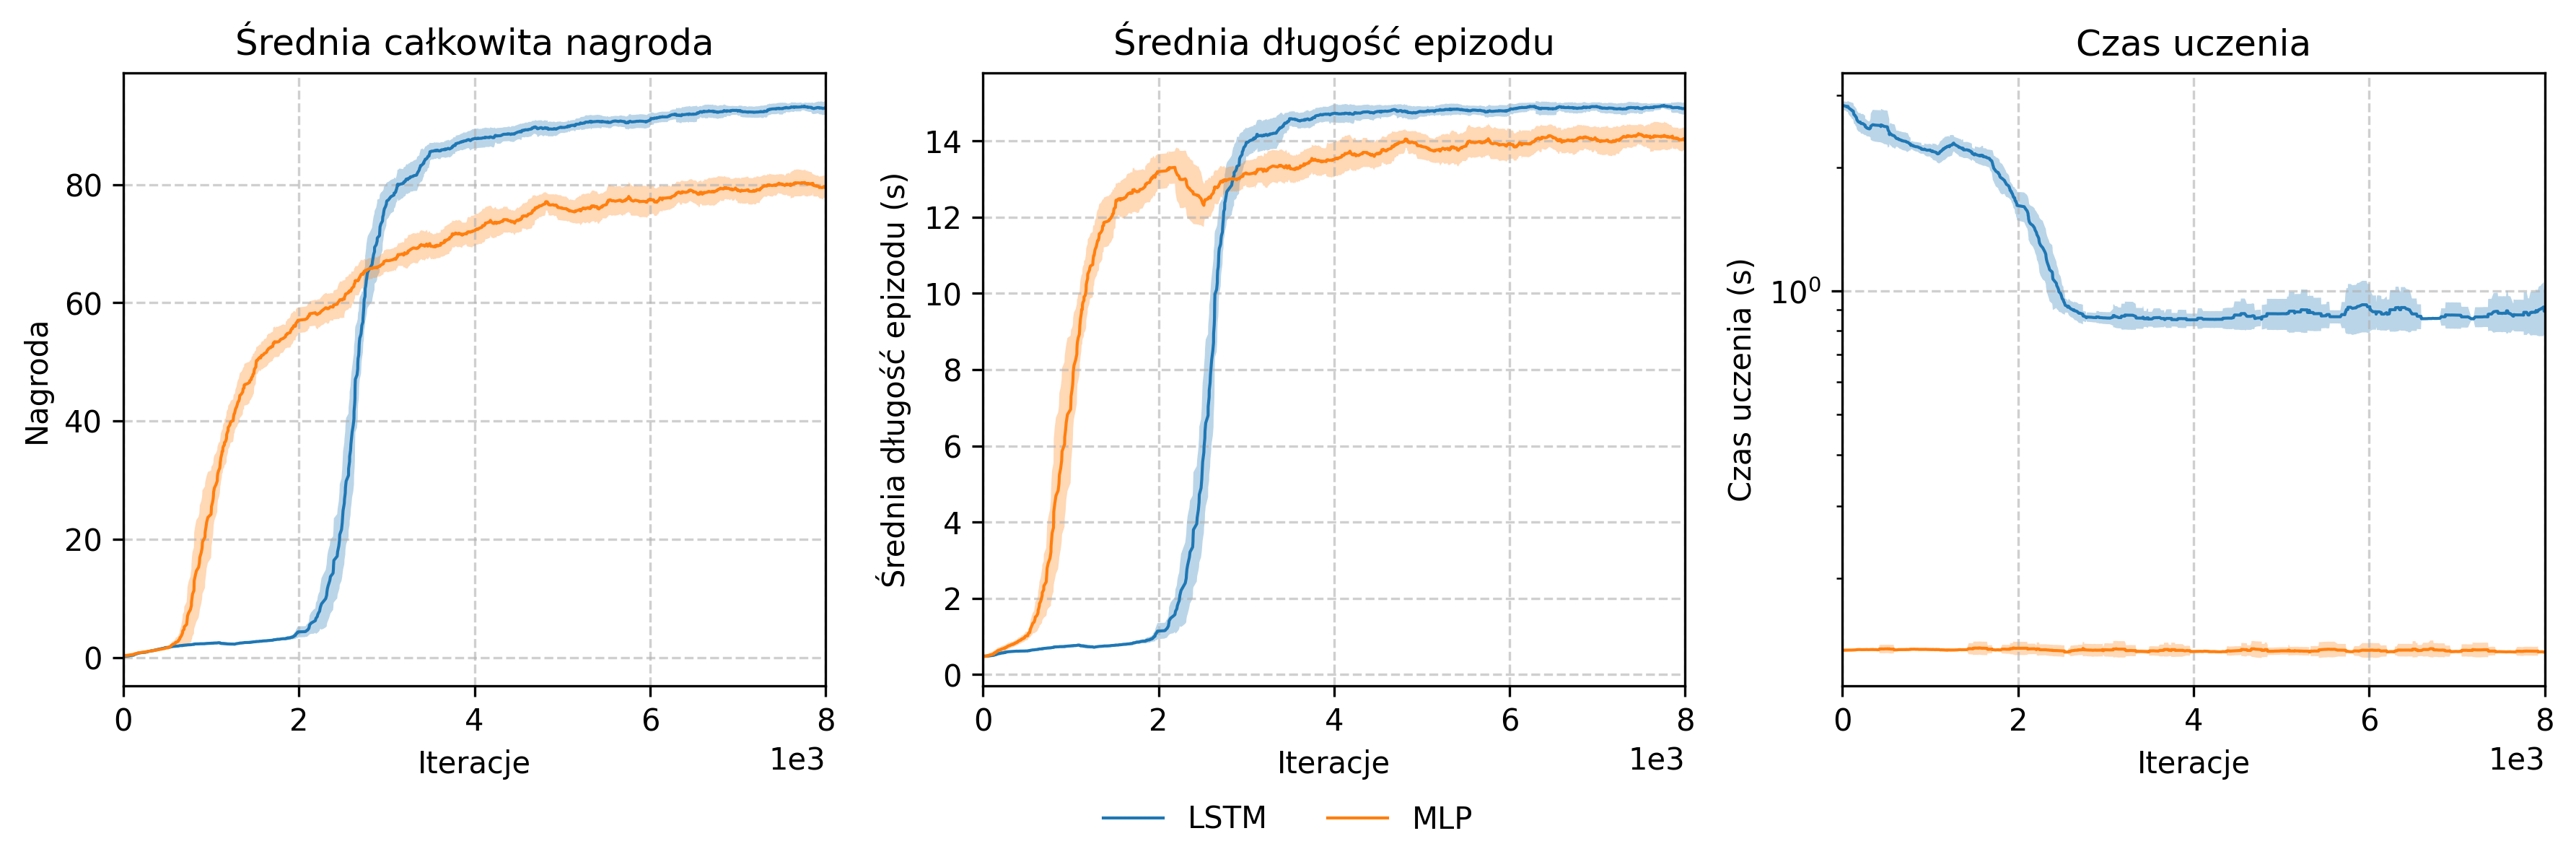

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def moving_stats(y, window=30):
    mean = np.array([
        y[max(0, i-window//2):min(len(y), i+window//2+1)].mean()
        for i in range(len(y))
    ])
    
    std = np.array([
        y[max(0, i-window//2):min(len(y), i+window//2+1)].std()
        for i in range(len(y))
    ])
    
    min_val = mean - std
    max_val = mean + std
    return mean, min_val, max_val


reward = {
    'LSTM': pd.read_csv(f'data/LSTM/total_reward.csv'),
    'MLP': pd.read_csv(f'data/MLP/total_reward.csv')
}
learning_time = {
    'LSTM': pd.read_csv(f'data/LSTM/learning_time.csv'),
    'MLP': pd.read_csv(f'data/MLP/learning_time.csv')
}
episode_length = {
    'LSTM': pd.read_csv(f'data/LSTM/episode_length.csv'),
    'MLP': pd.read_csv(f'data/MLP/episode_length.csv')
}
for key in episode_length.keys():
    episode_length[key]['Value'] = episode_length[key]['Value'] * 0.02
stats = {
    "Średnia całkowita nagroda": reward,
    "Średnia długość epizodu": episode_length,
    "Czas uczenia": learning_time
}

handles_all = []
labels_all = []


fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=300)
axes = axes.flatten()
for ax, (title, value) in zip(axes, stats.items()):
    for key, df in value.items():
        x = df['Step'].values
        y = df['Value'].values

        mean, min_val, max_val = moving_stats(y)

        line, = ax.plot(x, mean, linewidth=1, label=f'{key}')
        ax.fill_between(x, min_val, max_val, alpha=0.3)
        
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_xlim(0, 8_000)
    ax.set_xlabel('Iteracje')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    if title == "Czas uczenia":
        ax.semilogy()
        ax.set_ylabel('Czas uczenia (s)')
    if title == "Średnia długość epizodu":
        ax.set_ylabel('Średnia długość epizodu (s)')
    if title == "Średnia całkowita nagroda":
        ax.set_ylabel('Nagroda')
    handles, labels = ax.get_legend_handles_labels()
    for h, l in zip(handles, labels):
        if l not in labels_all:
            labels_all.append(l)
            handles_all.append(h)

fig.legend(handles_all, labels_all, loc='lower center', ncol=len(labels_all), frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()